In [152]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from patsy import dmatrix

%matplotlib inline
%config InlineBackend.figure_format = "retina"

RANDOM_SEED = 8927
az.style.use("arviz-darkgrid")

In [153]:
try:
    blossom_data = pd.read_csv(Path("..", "data", "cherry_blossoms.csv"), sep=";")
except FileNotFoundError:
    blossom_data = pd.read_csv(pm.get_data("cherry_blossoms.csv"), sep=";")


blossom_data.dropna().describe()

,year,doy,temp,temp_upper,temp_lower
count,787.000000,787.00000,787.000000,787.000000,787.000000
mean,1533.395172,104.92122,6.100356,6.937560,5.263545
std,291.122597,6.25773,0.683410,0.811986,0.762194
min,851.000000,86.00000,4.690000,5.450000,2.610000
25%,1318.000000,101.00000,5.625000,6.380000,4.770000
50%,1563.000000,105.00000,6.060000,6.800000,5.250000
75%,1778.500000,109.00000,6.460000,7.375000,5.650000
max,1980.000000,124.00000,8.300000,12.100000,7.740000


In [154]:
X_train = pd.read_csv("Nephytyidae/X_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_train = pd.read_csv("Nephytyidae/y_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

X_test = pd.read_csv("Nephytyidae/X_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_test = pd.read_csv("Nephytyidae/y_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

X_train = np.log1p(X_train)
X_test = np.log1p(X_test)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [155]:
X_viz = pd.concat([X_train, y_train], axis=1)
X_viz = X_viz.rename(columns={"Zn.1": "Zn"})

In [156]:
X_viz = X_viz[X_viz["Nephtyidae"] <= 500]
X_viz

,Gravel,Mud,Totalorganiccontent,Sand,Fe.1,As.1,Ba.1,Be.1,Cd.1,Co.1,Cu.1,Cr.1,Mn.1,Hg.1,Ni.1,Pb.1,V.1,Zn,#metalsenriched,Nephtyidae
0,3.391159,3.760744,1.015376,3.411782,0.734948,0.489325,0.556030,0.727170,0.222257,0.619834,2.170896,0.557725,0.629341,0.908221,0.599696,0.820041,0.709154,0.756335,2.079442,3.396353
1,0.000000,4.547490,1.922481,2.028780,0.705361,0.621363,0.894712,0.547142,0.476142,1.198839,2.739886,0.760758,0.534853,0.498630,0.633658,0.920486,0.612430,1.236829,2.079442,3.396353
2,0.000000,4.501774,2.076284,2.470047,0.580264,0.481636,0.625743,0.534685,0.377033,0.437611,1.483405,0.568528,0.433159,0.511047,0.503206,0.803886,0.604124,0.641183,1.098612,3.396353
3,0.074913,4.023927,1.696213,3.828684,0.604956,0.619302,0.720134,0.539028,0.711964,0.487287,1.976721,0.622631,0.478682,0.585618,0.554835,0.820369,0.724636,0.897902,1.945910,0.000000
4,0.175097,4.242612,1.296775,3.472564,0.612695,0.324108,0.577140,0.523710,0.119190,0.520506,0.753505,0.534334,0.505216,0.281733,0.540431,0.502661,0.573348,0.391925,0.693147,4.624900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.000000,4.461179,0.943218,2.735048,0.614949,0.529604,0.400982,0.559039,1.672337,0.712872,2.432813,1.645161,0.537416,0.558325,1.076137,0.536817,0.588525,1.536079,1.945910,3.790591
299,1.017626,4.181060,1.205801,3.549567,0.608818,0.495788,0.426626,0.565671,1.814319,0.756117,2.794093,3.231589,0.509026,0.807682,1.295702,0.636338,0.696937,1.214977,2.197225,0.000000
300,0.000000,4.568347,1.229197,1.725510,0.575275,0.511669,0.520480,0.282968,0.245291,0.524248,1.101634,1.453184,0.325760,0.440500,0.510941,0.522108,0.518544,0.583513,1.098612,2.736153
301,0.903552,4.223780,1.440304,3.473224,0.595509,0.500138,0.426369,0.416293,0.453484,0.749681,2.214191,3.171684,0.399409,0.434172,1.094489,0.445132,0.711125,0.675330,1.791759,0.000000


<Axes: title={'center': 'Sediment Data'}, xlabel='Zn', ylabel='Nephtyidae'>

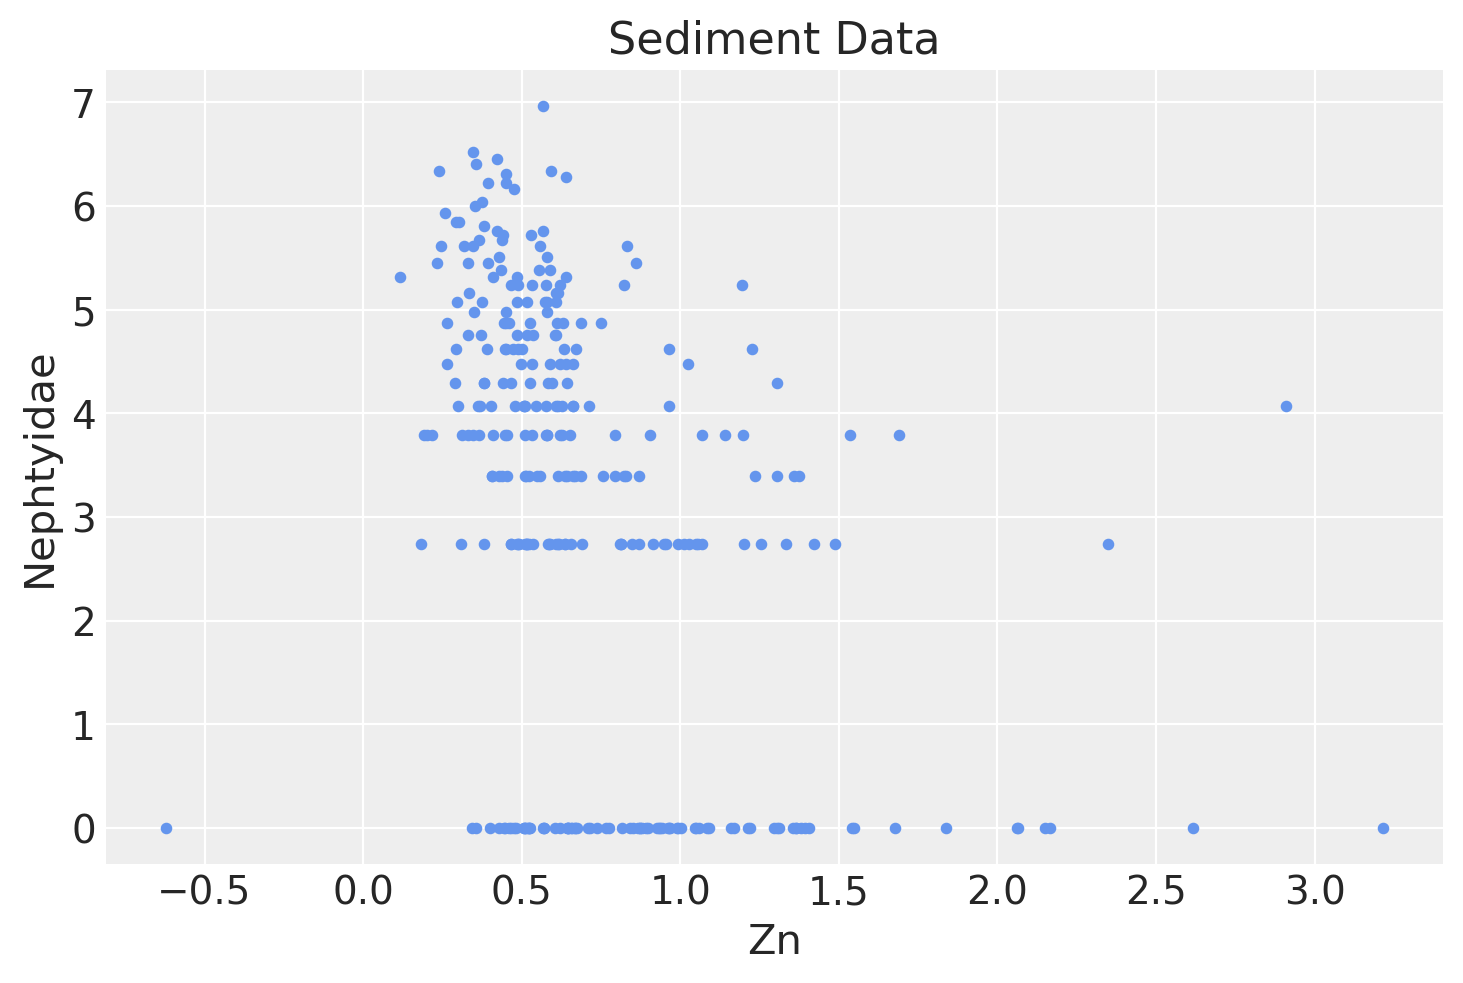

In [157]:
X_viz.plot.scatter(
    "Zn", "Nephtyidae", color="cornflowerblue", s=10, title="Sediment Data", ylabel="Nephtyidae"
)

In [158]:
num_knots = 8
knot_list = np.quantile(X_viz.Nephtyidae, np.linspace(0, 1, num_knots))
knot_list

array([0.        , 0.        , 2.73615268, 3.39635341, 3.79059066,
       4.62490039, 5.23940411, 6.9605457 ])

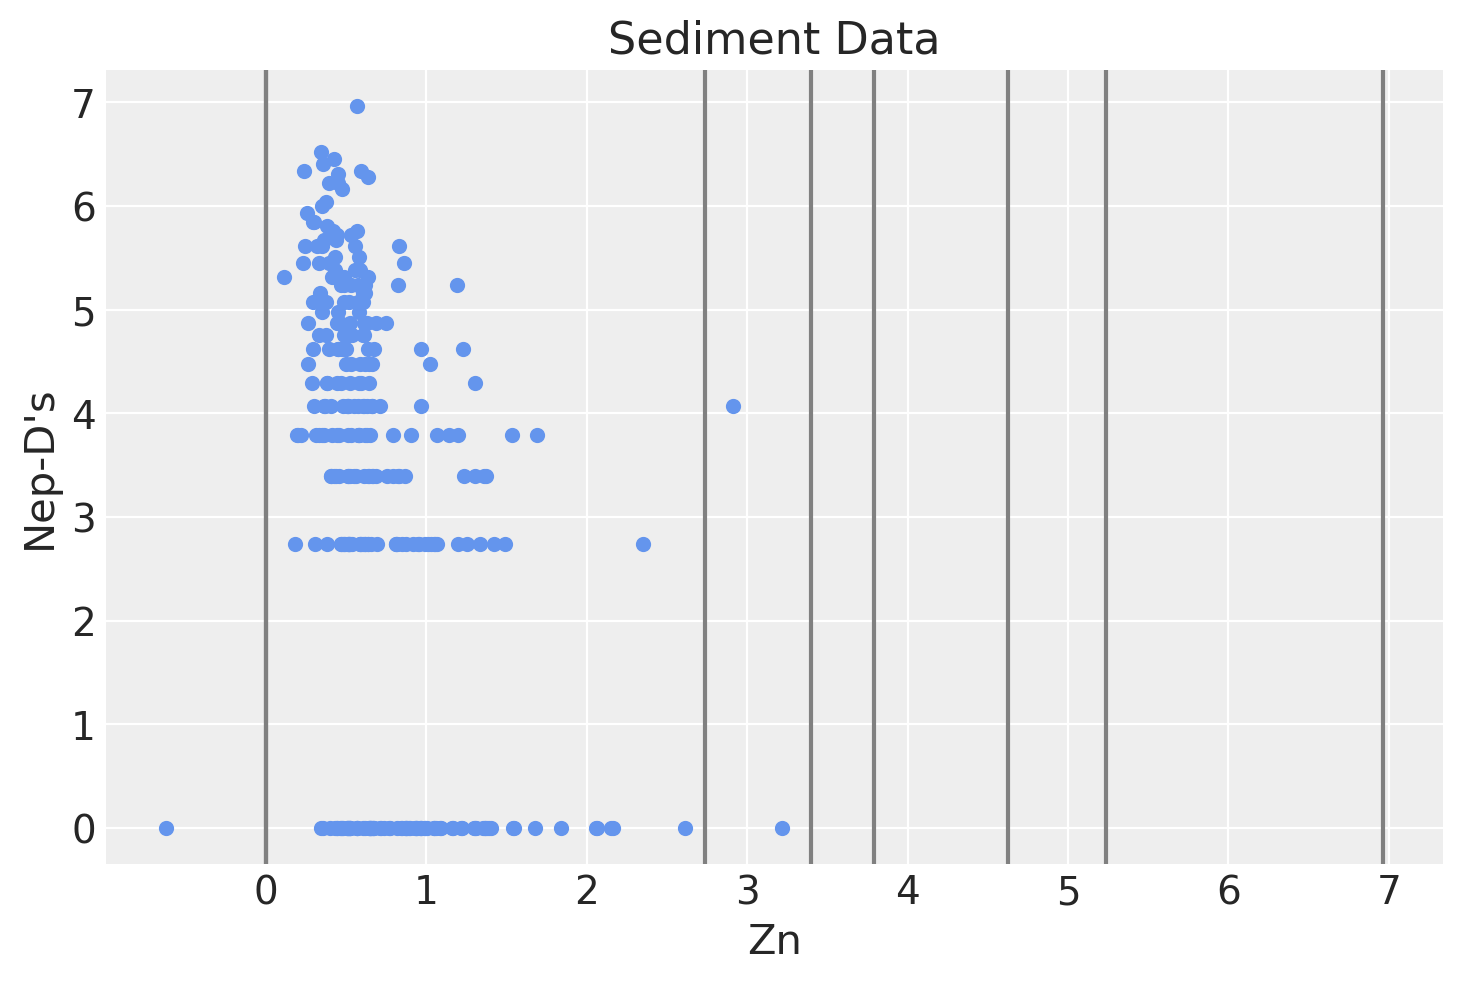

In [159]:
X_viz.plot.scatter(
    "Zn", "Nephtyidae", color="cornflowerblue", title="Sediment Data", ylabel="Nep-D's"
)
for knot in knot_list:
    plt.gca().axvline(knot, color="grey")

In [160]:
lower_bound = X_viz["Zn"].min()
upper_bound = X_viz["Zn"].max()
knots = np.linspace(lower_bound, upper_bound, num=4)

B = dmatrix(
    "bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True) - 1",
    {"Zn": X_viz["Zn"].values},
)
B

DesignMatrix with shape (303, 6)
  Columns:
    ['bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[0]',
     'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[1]',
     'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[2]',
     'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[3]',
     'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[4]',
     'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)[5]']
  Terms:
    'bs(Zn, knots=knots[1:-1], degree=3, include_intercept=True)' (columns 0:6)
  (to view full data, use np.asarray(this_obj))

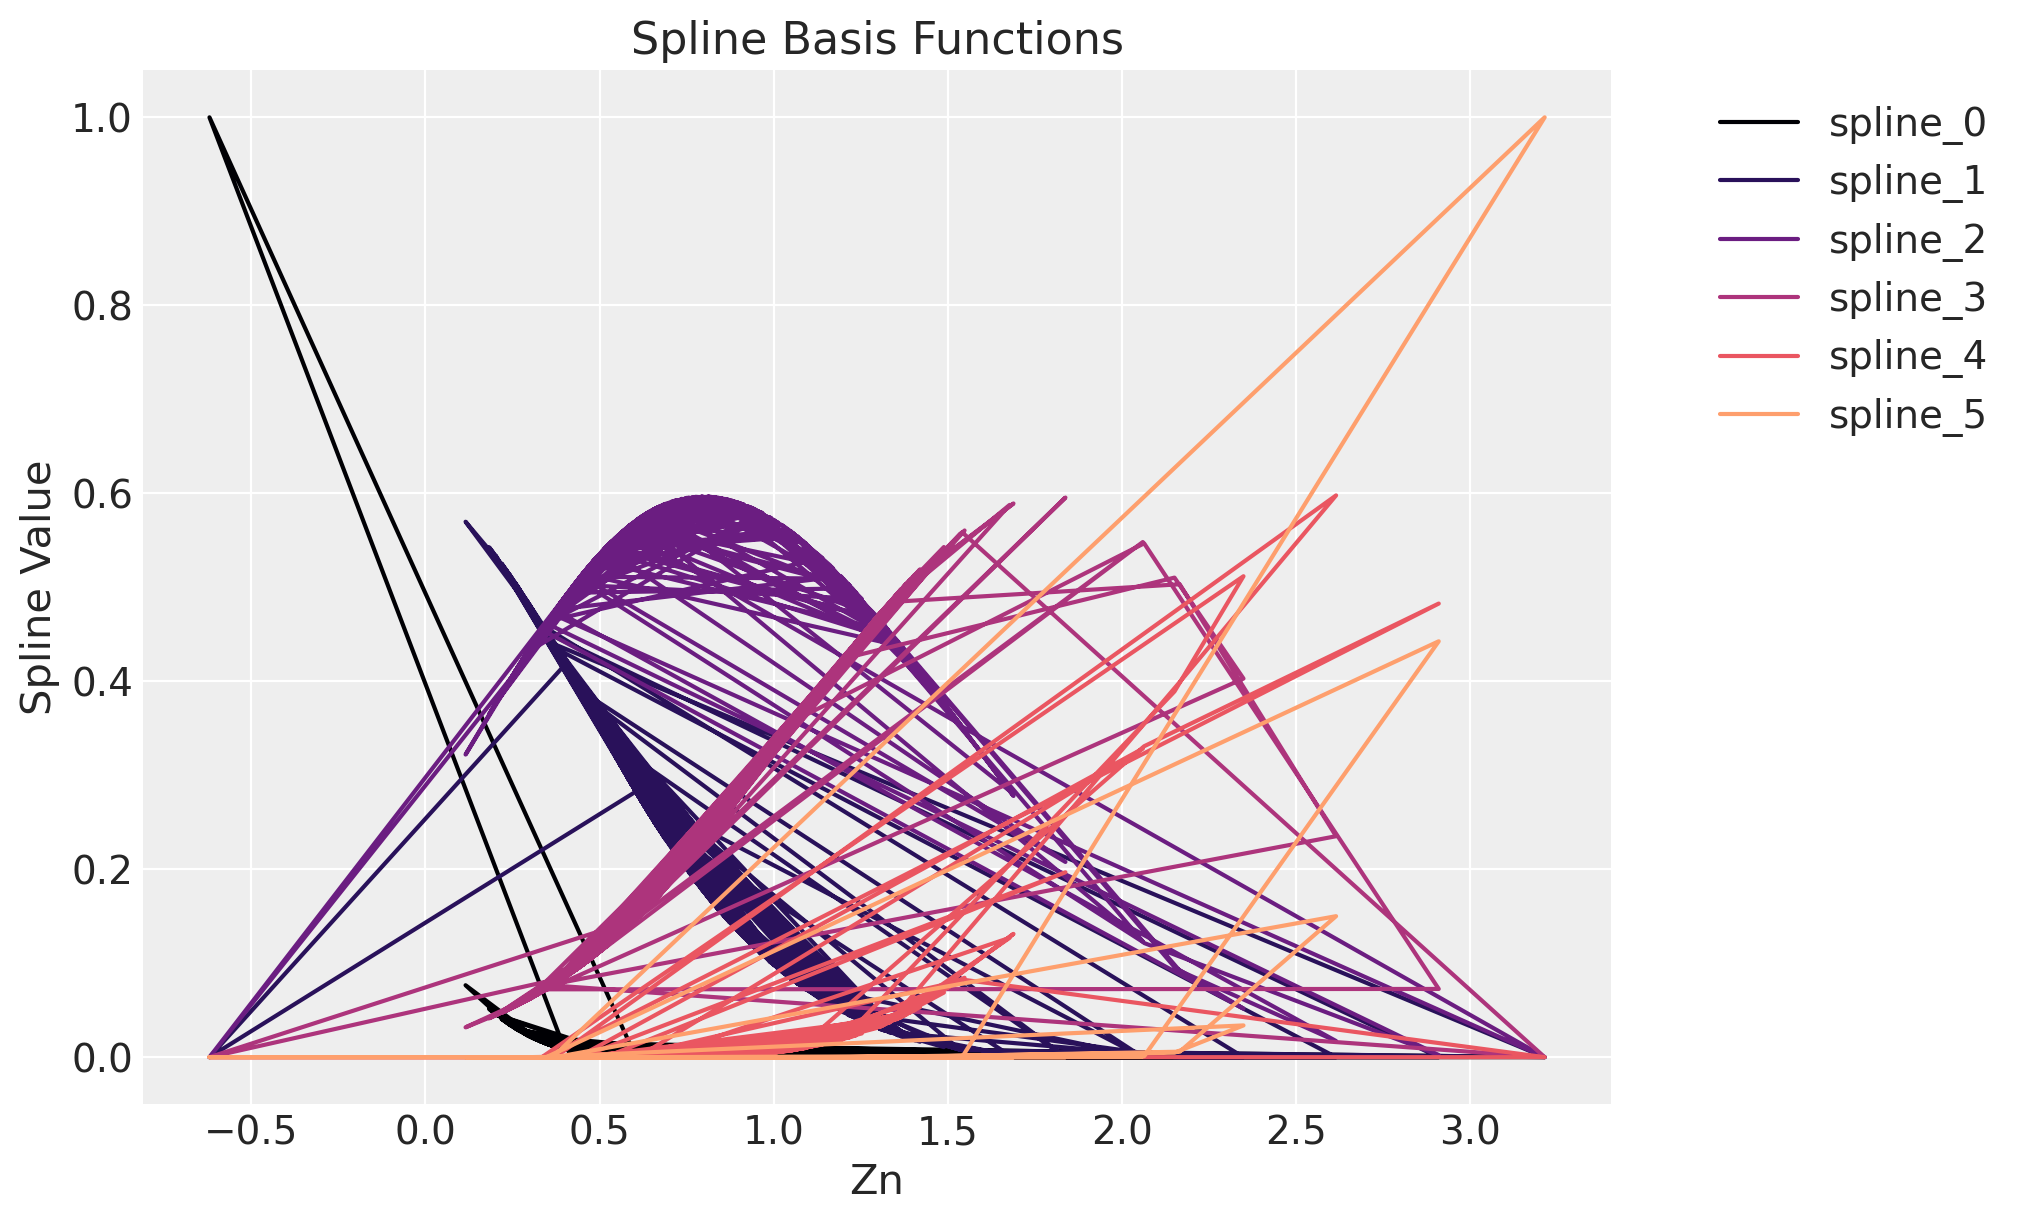

In [161]:
spline_df = (
    pd.DataFrame(B, columns=[f"spline_{i}" for i in range(B.shape[1])])  # Add column names
    .assign(Zn=X_viz["Zn"].values)  # Ensure Zn.1 is included
    .melt("Zn", var_name="spline_i", value_name="value")  # Melt for visualization
)

# Visualization
color = plt.cm.magma(np.linspace(0, 0.80, len(spline_df["spline_i"].unique())))
fig, ax = plt.subplots(figsize=(10, 6))
for (i, df), c in zip(spline_df.groupby("spline_i"), color):
    ax.plot(df["Zn"], df["value"], label=i, color=c)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_title("Spline Basis Functions")
ax.set_xlabel("Zn")
ax.set_ylabel("Spline Value")
plt.show()

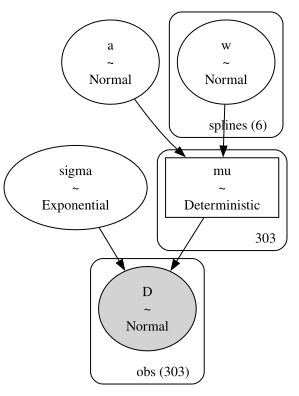

In [162]:
COORDS = {
    "splines": np.arange(B.shape[1]),  # Spline basis dimensions
    "obs": np.arange(len(X_viz.Nephtyidae))  # Observations
}
with pm.Model(coords=COORDS) as spline_model:
    a = pm.Normal("a", 100, 5)
    w = pm.Normal("w", mu=0, sigma=3, size=B.shape[1], dims="splines")
    mu = pm.Deterministic("mu", a + pm.math.dot(np.asarray(B, order="F"), w.T))
    sigma = pm.Exponential("sigma", 1)
    D = pm.Normal("D", mu=mu, sigma=sigma, observed=X_viz.Nephtyidae, dims="obs")
pm.model_to_graphviz(spline_model)

In [163]:
with spline_model:
    idata = pm.sample_prior_predictive()
    idata.extend(pm.sample(draws=1000, tune=1000, random_seed=RANDOM_SEED, chains=4))
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [D, a, sigma, w]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, w, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
Sampling: [D]


Output()

In [164]:
az.summary(idata, var_names=["a", "w", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,8.500,1.263,6.122,10.833,0.042,0.029,920.0,1653.0,1.0
w[0],-6.242,1.868,-9.800,-2.812,0.043,0.030,1923.0,2366.0,1.0
w[1],-0.605,1.541,-3.395,2.274,0.048,0.034,1009.0,2005.0,1.0
w[2],-7.027,1.534,-9.884,-4.165,0.042,0.029,1365.0,2228.0,1.0
w[3],-7.731,1.631,-10.853,-4.751,0.051,0.036,1036.0,1918.0,1.0
w[4],-5.763,1.963,-9.638,-2.180,0.044,0.031,1963.0,2487.0,1.0
w[5],-5.894,1.807,-9.194,-2.421,0.042,0.030,1832.0,2845.0,1.0
sigma,1.851,0.075,1.721,1.999,0.001,0.001,2618.0,2076.0,1.0


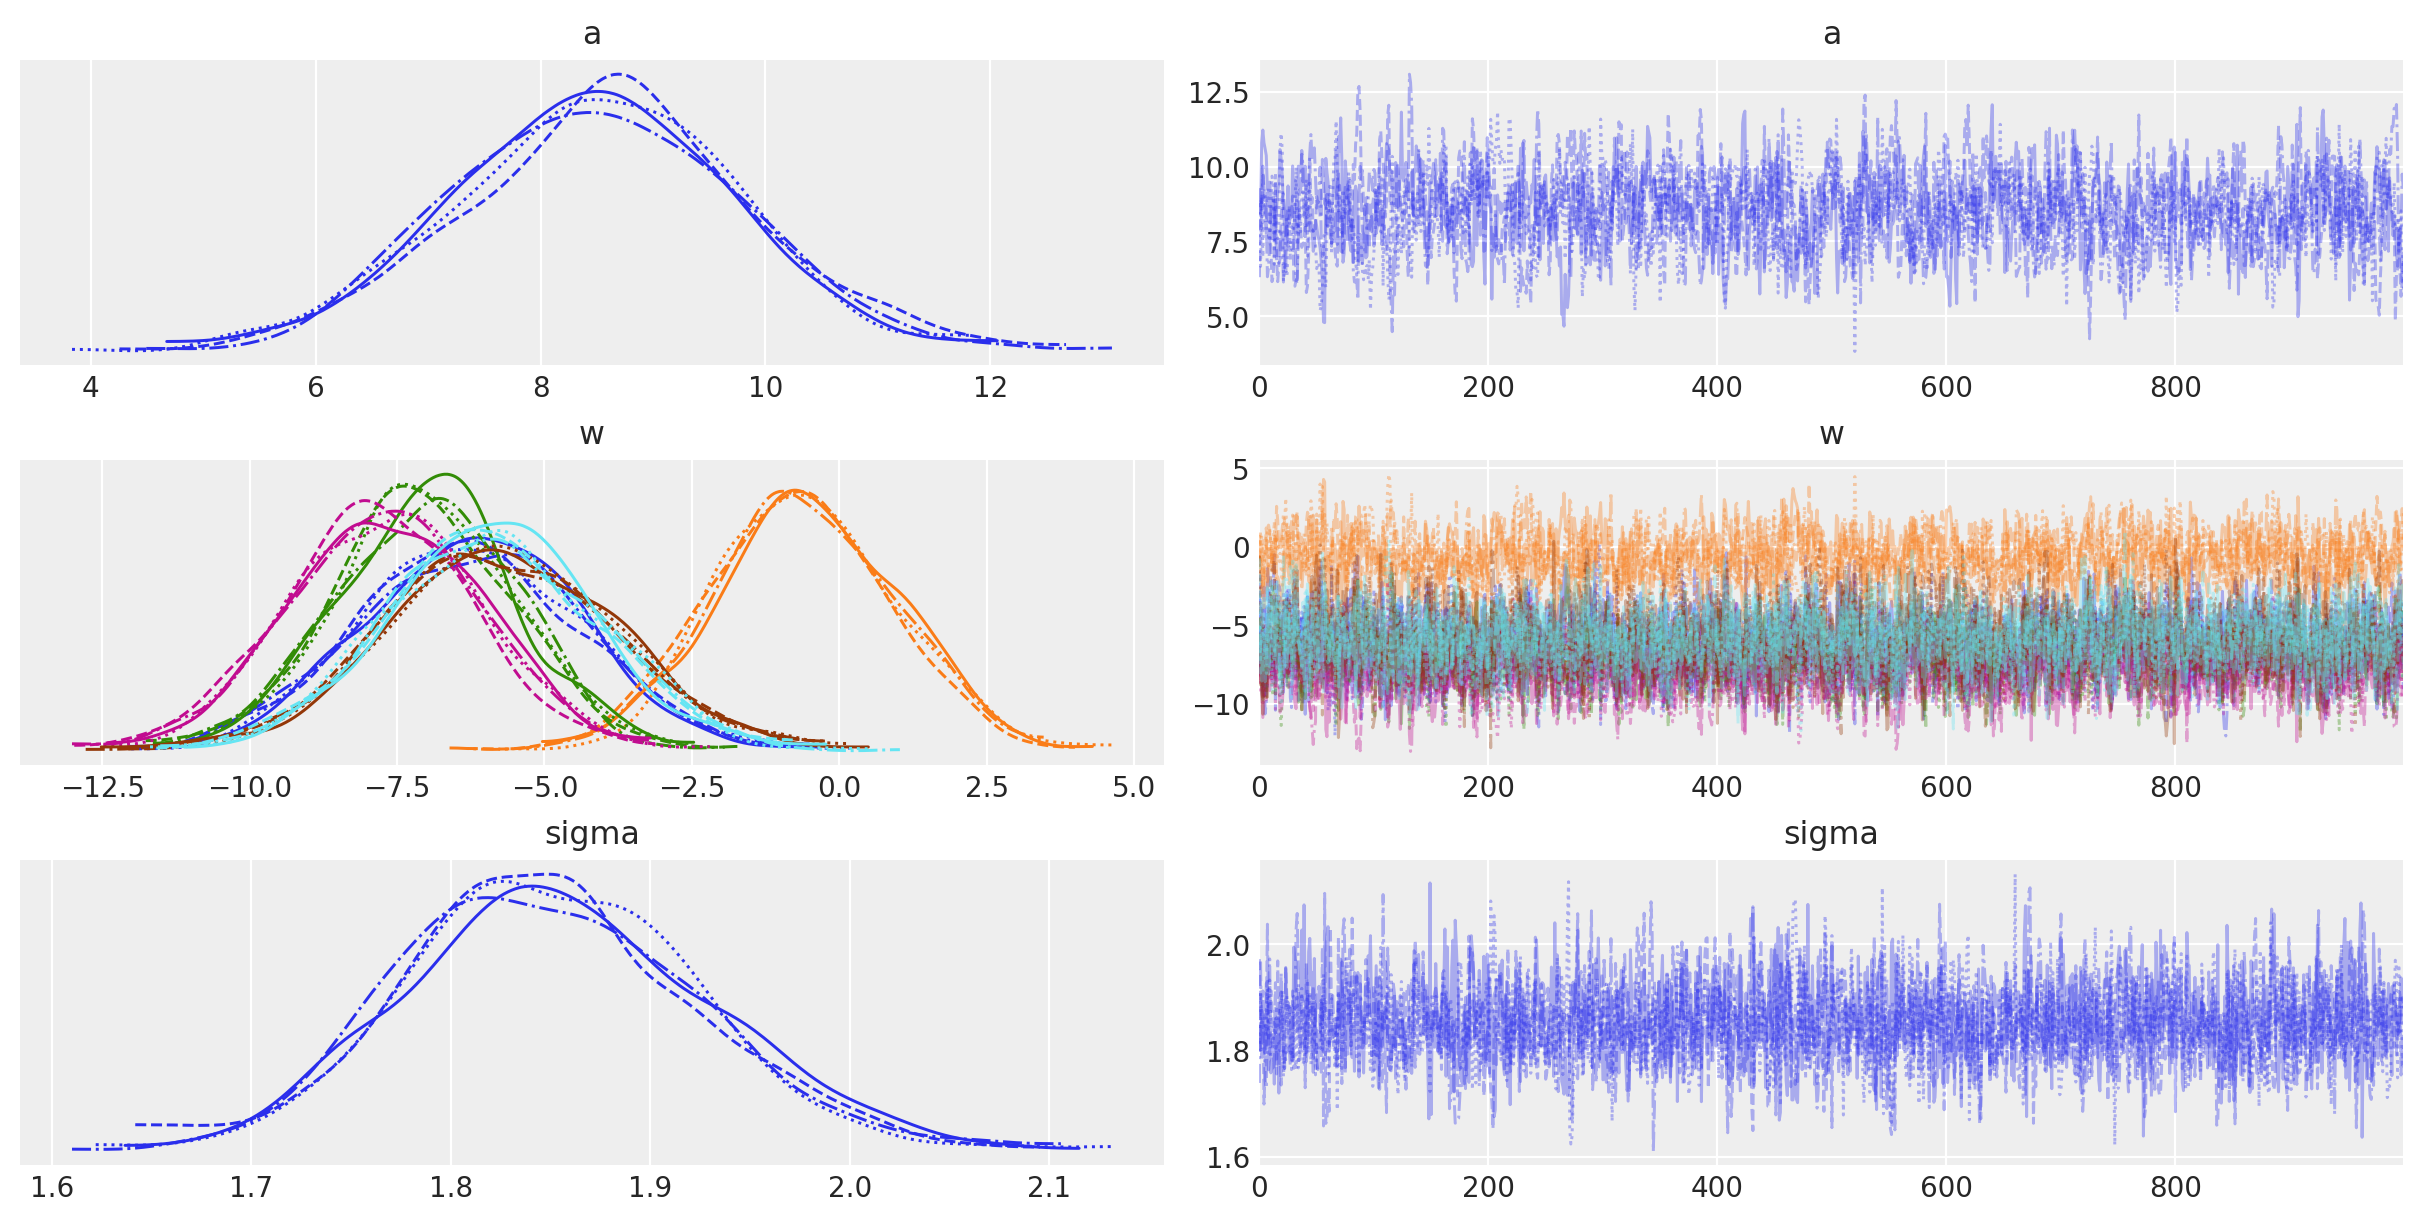

In [165]:
az.plot_trace(idata, var_names=["a", "w", "sigma"]);

array([<Axes: title={'center': '94.0% HDI'}>,
       <Axes: title={'center': 'r_hat'}>], dtype=object)

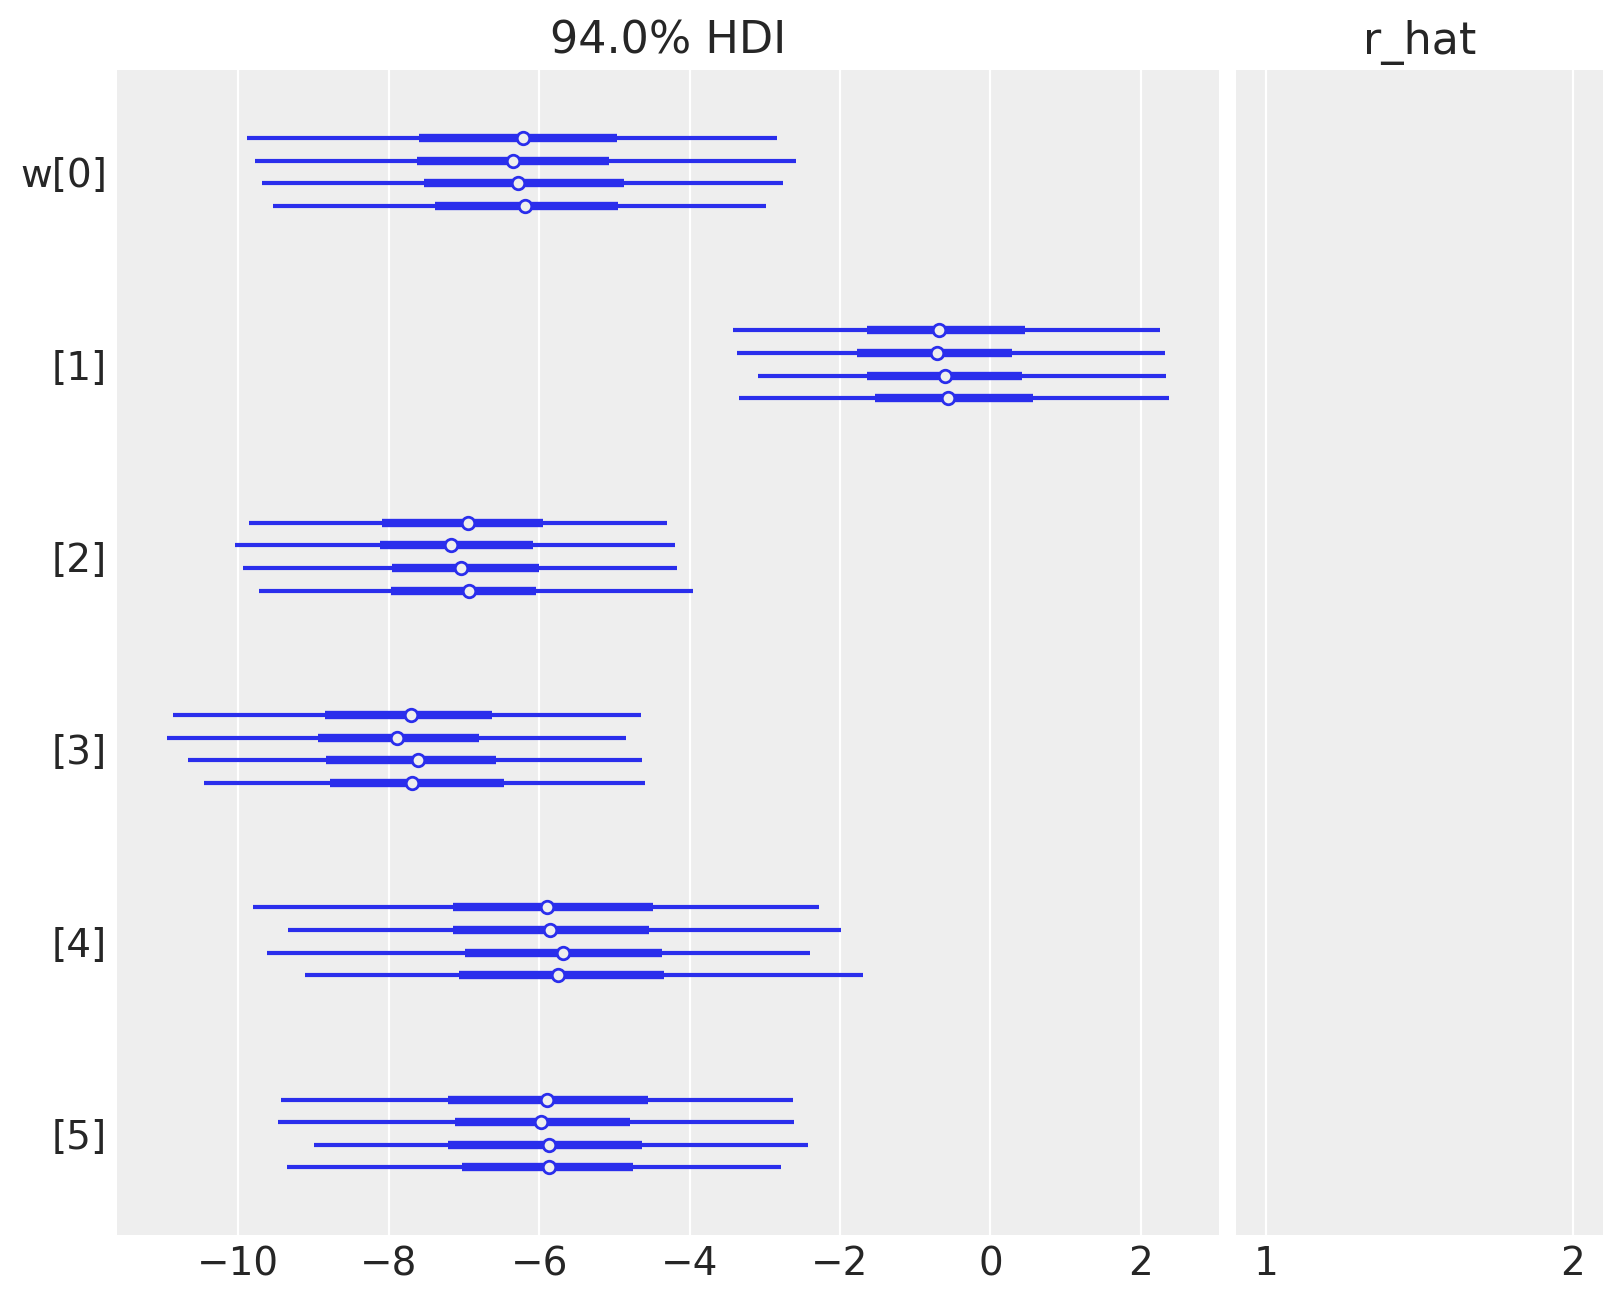

In [166]:
az.plot_forest(idata, var_names=["w"], combined=False, r_hat=True)

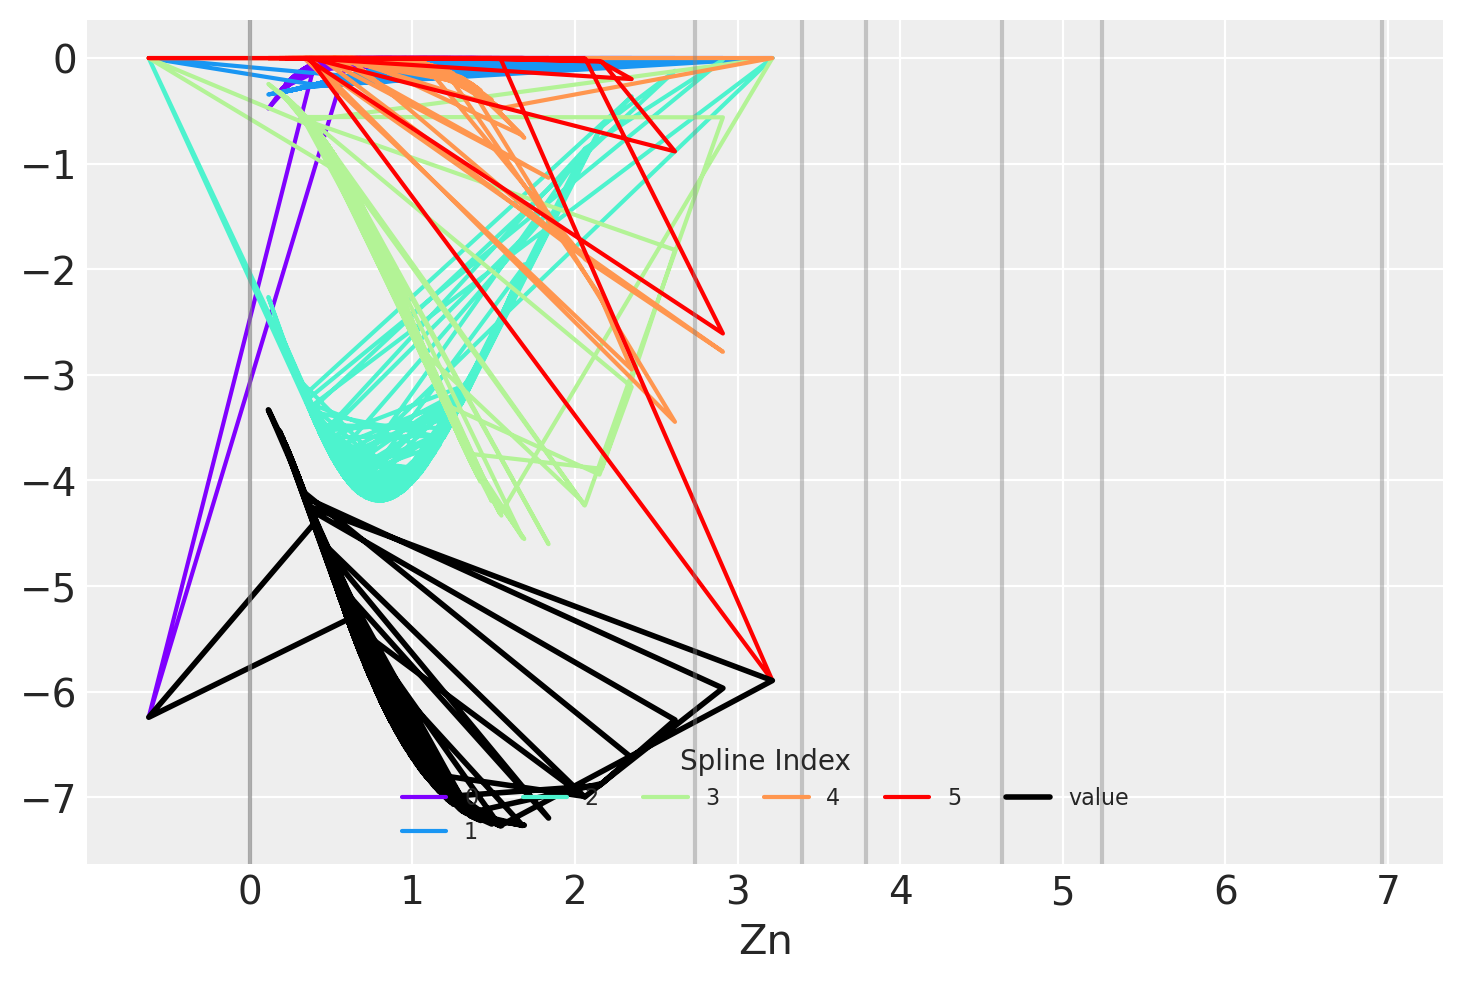

In [167]:
wp = idata.posterior["w"].mean(("chain", "draw")).values

spline_df = (
    pd.DataFrame(B * wp.T)
    .assign(Zn=X_viz.Zn.values)
    .melt("Zn", var_name="spline_i", value_name="value")
)

spline_df_merged = (
    pd.DataFrame(np.dot(B, wp.T))
    .assign(Zn=X_viz.Zn.values)
    .melt("Zn", var_name="spline_i", value_name="value")
)


color = plt.cm.rainbow(np.linspace(0, 1, len(spline_df.spline_i.unique())))
fig = plt.figure()
for i, c in enumerate(color):
    subset = spline_df.query(f"spline_i == {i}")
    subset.plot("Zn", "value", c=c, ax=plt.gca(), label=i)
spline_df_merged.plot("Zn", "value", c="black", lw=2, ax=plt.gca())
plt.legend(title="Spline Index", loc="lower center", fontsize=8, ncol=6)

for knot in knot_list:
    plt.gca().axvline(knot, color="grey", alpha=0.4)

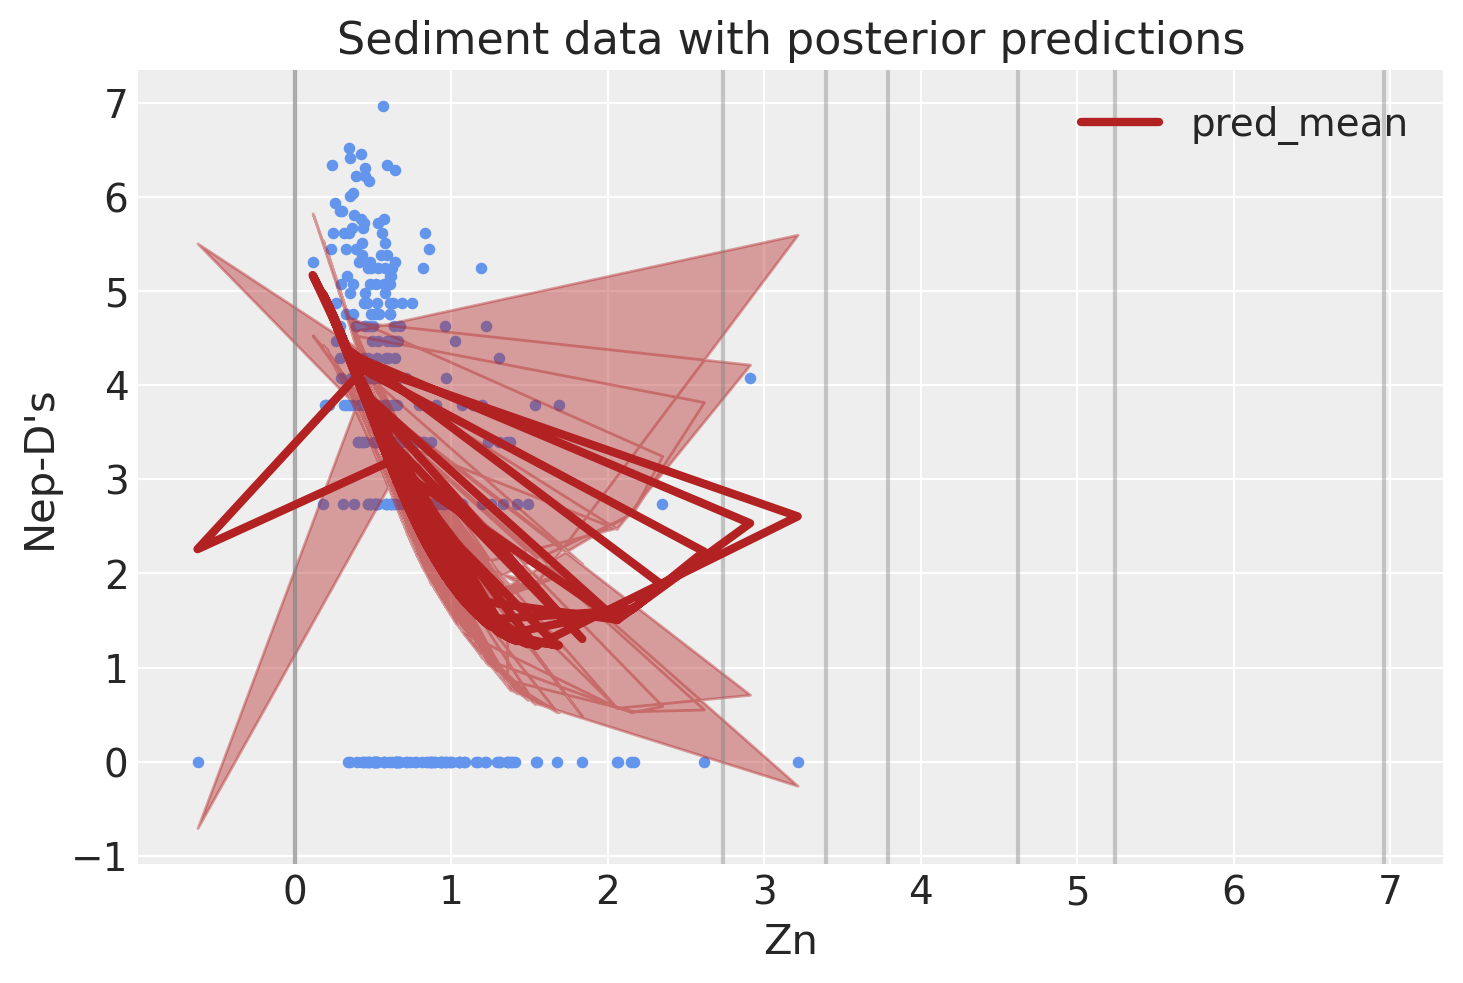

In [168]:
post_pred = az.summary(idata, var_names=["mu"]).reset_index(drop=True)
X_viz_post = X_viz.copy().reset_index(drop=True)
X_viz_post["pred_mean"] = post_pred["mean"]
X_viz_post["pred_hdi_lower"] = post_pred["hdi_3%"]
X_viz_post["pred_hdi_upper"] = post_pred["hdi_97%"]

X_viz.plot.scatter(
    "Zn",
    "Nephtyidae",
    color="cornflowerblue",
    s=10,
    title="Sediment data with posterior predictions",
    ylabel="Nep-D's",
)
for knot in knot_list:
    plt.gca().axvline(knot, color="grey", alpha=0.4)

X_viz_post.plot("Zn", "pred_mean", ax=plt.gca(), lw=3, color="firebrick")
plt.fill_between(
    X_viz_post.Zn,
    X_viz_post.pred_hdi_lower,
    X_viz_post.pred_hdi_upper,
    color="firebrick",
    alpha=0.4,
)